In [14]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);

In [15]:
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000            # number of time steps
DT = T_HORIZON / (T - 1)   # 3.6036s — fixed for all sims

In [32]:
def get_vals_DC(I0, T=T, t_horizon=T_HORIZON):

    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid  # valid is your loss mask

def get_vals_pulse(I0, T=T, t_horizon=T_HORIZON):
    pass

def get_vals_GRF(T=T, t_horizon=T_HORIZON):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid  # valid is your loss mask

def gen_data_I_c(B, T=T, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    """
    Generates B trajectories of length T at random constant currents.
    Computes c_dot via finite difference / dt.
    """
    rng = np.random.default_rng(seed)

    V = np.zeros((B, T, 1))
    I = np.zeros((B, T, 1))
    dI = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))
    valid = np.zeros((B, T), dtype=bool)

    for i in trange(B):
        if currents == 'DC':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_DC(I0, T=T, t_horizon=T_HORIZON)
        elif currents == 'pulse':
            # t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_pulse(I0, T=T, t_horizon=T_HORIZON)
            pass
        elif currents == 'GRF':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_GRF(T=T, t_horizon=T_HORIZON)
        
        V[i, :, 0] = V_i
        I[i, :, 0] = I_i
        cn[i, :, 0] = cn_i
        cp[i, :, 0] = cp_i
        valid[i, :] = valid_i

        # dI(t): backward difference,  dI[0] = 0
        dI[i, 1:, 0] = np.diff(I_i)
        dI[i, 0,  0] = 0.0

        # Proper time derivative (backward/forward diff)
        cn_dot[i, :-1, 0] = np.diff(cn_i) / dt
        cp_dot[i, :-1, 0] = np.diff(cp_i) / dt

        # pad last entry
        cn_dot[i, -1, 0] = cn_dot[i, -2, 0]
        cp_dot[i, -1, 0] = cp_dot[i, -2, 0]

    return I, dI, V, cn, cn_dot, cp, cp_dot, valid

In [ ]:
B = 30
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = gen_data_I_c(B, T, currents='GRF')

100%|██████████| 30/30 [00:57<00:00,  1.92s/it]


In [ ]:
# np.savez('data_c_constI.npz', I=I, dI=dI, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, valid=valid)

def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data_c_constI.npz')

# data = np.load('GRF_data_c_dot.npz')

In [86]:
stats = {}

def fit():
    for name, arr in zip(['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot'], 
                         [I, dI, V, cn, cn_dot, cp, cp_dot]):
        stats[name] = (float(arr.mean()), float(max(arr.std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = fit()

# Normalize
I_n = transform(I, "I")
dI_n = transform(dI, "dI")
cn_n = transform(cn, "cn")
cp_n = transform(cp, "cp")
cn_dot_n = transform(cn_dot, "cn_dot")
cp_dot_n = transform(cp_dot, "cp_dot")

In [111]:
x = torch.tensor(np.concatenate([I_n, dI_n, cn_n, cp_n], axis=-1), dtype=torch.float32) # [B, T, 4]
y = torch.tensor(np.concatenate([cn_dot_n, cp_dot_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(valid, dtype=torch.float32)

# Split
split = int(0.8 * B)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]
mask_train, mask_test = mask[:split], mask[split:]

# Un-normalized for plotting
cn_test = cn[split:]
cp_test = cp[split:]
cn_dot_test = cn_dot[split:]
cp_dot_test = cp_dot[split:]
I_test = I[split:]
dI_test = dI[split:]
print('Shapes:', mask_train.shape, y.shape, cn_test.shape, cp_test.shape, cn_dot_test.shape, cp_dot_test.shape)

train_loader = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=12, shuffle=True)

Shapes: torch.Size([24, 1000]) torch.Size([30, 1000, 2]) (6, 1000, 1) (6, 1000, 1) (6, 1000, 1) (6, 1000, 1)


In [105]:
''' Mk 1 '''
# class Net(nn.Module):
#     def __init__(self, input_size=4, hidden_size=128):
#         super(Net, self).__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_size, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
#         )
    
#     def forward(self, x):
#         return self.net(x)

''' Mk 2: LSTM '''
# class Net(nn.Module):
#     def __init__(self, input_size=4, hidden_size=64):
#         super(Net, self).__init__()
#         self.net = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
#         self.head = nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
    
#     def forward(self, x):
#         out, _ = self.net(x)
#         x = self.head(out)
#         return x
    
''' Mk3: GRU '''
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super(Net, self).__init__()
        self.net = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
    
    def forward(self, x):
        out, _ = self.net(x)
        x = self.head(out)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [106]:
def masked_mse(pred, target, mask):
    # pred, target: (B, T, 2)   mask: (B, T)
    err = (pred - target) ** 2    # (B, T, 2)
    m = mask.unsqueeze(-1)        # (B, T, 1) — broadcasts over 2 outputs
    return (err * m).sum() / (m.sum() * 2)

def training(epochs=30):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0.0

        for x_b, y_b, mask_b in train_loader:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            pred = model(x_b)   # [B, T, 2]
            loss = masked_mse(pred, y_b, mask_b)
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()

        last = ep_loss / len(train_loader)  # Average loss per batch
        history["loss"].append(last)
        print(f"Epoch {ep+1} | loss {last:.3e}")

    return history

history = training(epochs=150)

Epoch 1 | loss 1.031e+00
Epoch 2 | loss 9.966e-01
Epoch 3 | loss 9.665e-01
Epoch 4 | loss 9.447e-01
Epoch 5 | loss 9.243e-01
Epoch 6 | loss 9.090e-01
Epoch 7 | loss 8.969e-01
Epoch 8 | loss 8.917e-01
Epoch 9 | loss 8.893e-01
Epoch 10 | loss 8.891e-01
Epoch 11 | loss 8.843e-01
Epoch 12 | loss 8.794e-01
Epoch 13 | loss 8.737e-01
Epoch 14 | loss 8.718e-01
Epoch 15 | loss 8.687e-01
Epoch 16 | loss 8.659e-01
Epoch 17 | loss 8.629e-01
Epoch 18 | loss 8.565e-01
Epoch 19 | loss 8.524e-01
Epoch 20 | loss 8.475e-01
Epoch 21 | loss 8.434e-01
Epoch 22 | loss 8.375e-01
Epoch 23 | loss 8.315e-01
Epoch 24 | loss 8.240e-01
Epoch 25 | loss 8.156e-01
Epoch 26 | loss 8.102e-01
Epoch 27 | loss 8.016e-01
Epoch 28 | loss 7.934e-01
Epoch 29 | loss 7.902e-01
Epoch 30 | loss 7.840e-01
Epoch 31 | loss 7.792e-01
Epoch 32 | loss 7.749e-01
Epoch 33 | loss 7.726e-01
Epoch 34 | loss 7.669e-01
Epoch 35 | loss 7.592e-01
Epoch 36 | loss 7.554e-01
Epoch 37 | loss 7.493e-01
Epoch 38 | loss 7.438e-01
Epoch 39 | loss 7.377

In [107]:
def rollout(idx=0):
    model.eval()

    # Initial un-normalized values for the chosen trajectory
    c0_n = cn_test[idx, 0, 0]
    c0_p = cp_test[idx, 0, 0]

    cn_min = cn_test[idx].min()  # For explicit stopper criterion

    cn_traj = np.zeros(T, dtype=np.float32)
    cp_traj = np.zeros(T, dtype=np.float32)
    cn_dot_traj = np.zeros(T, dtype=np.float32)
    cp_dot_traj = np.zeros(T, dtype=np.float32)
    cn_traj[0] = c0_n
    cp_traj[0] = c0_p

    steps_run = 1

    with torch.no_grad():
        for t in range(T - 1):
            # build normalised input for this step
            I_val  = float(I_test[idx, t, 0])
            dI_val = float(dI_test[idx, t, 0])
            
            x_t = np.array([[
                transform(np.array([[[I_val]]]),  "I")[0,0,0],  # True
                transform(np.array([[[dI_val]]]), "dI")[0,0,0], # True
                transform(np.array([[[cn_traj[t]]]]), "cn")[0,0,0],     # Predicted
                transform(np.array([[[cp_traj[t]]]]), "cp")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)
            # print('Input x_t shape:', x_t.shape)
            # Predict on initial state (1, 4)
            pred = model(torch.tensor(x_t))              # (1, 2)
            # print(pred)
            dc_n = inverse_transform(pred[0,0].numpy().reshape(1,1,1), "cn_dot")[0,0,0]
            dc_p = inverse_transform(pred[0,1].numpy().reshape(1,1,1), "cp_dot")[0,0,0]

            cn_traj[t+1] = cn_traj[t] + dc_n * DT
            cp_traj[t+1] = cp_traj[t] + dc_p * DT
            cn_dot_traj[t] = dc_n
            cp_dot_traj[t] = dc_p

            steps_run += 1

            # Stop if concentration goes below a threshold
            if cn_traj[t+1] < cn_min:  # Depleated battery
                break

    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run

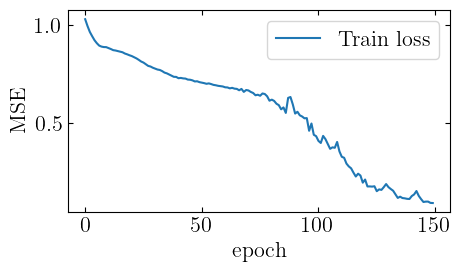

In [108]:
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))
ax1.plot(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()
plt.tight_layout()

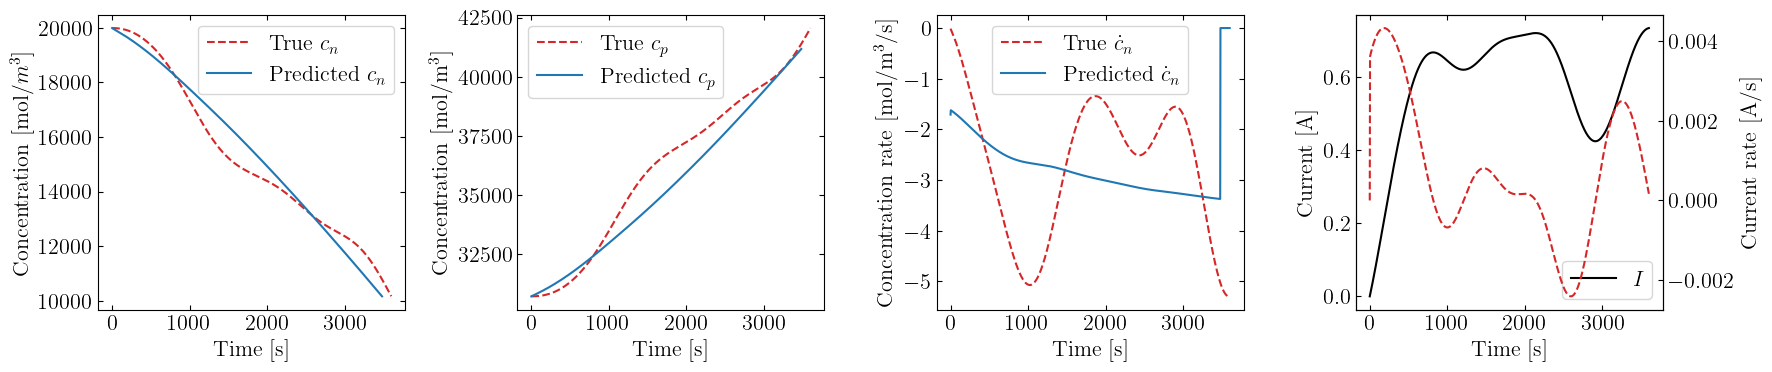

In [109]:
def plot_rollout(idx=0):
    cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx)

    # Ground truth valid length
    n_gt = int(mask_test[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping

    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * DT             # physical time axis for NN

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # --- cn ---
    axes[0].plot(t_gt, cn_test[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[0].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel(r"Concentration [mol/$m^3$]")
    axes[0].legend()

    # --- cp ---
    axes[1].plot(t_gt, cp_test[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_p$")
    axes[1].plot(t_nn, cp_euler[:n_nn], color="tab:blue", label="Predicted $c_p$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cn_dot ---
    axes[2].plot(t_gt, cn_dot_test[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[2].plot(t_gt, cn_dot_euler[:n_gt], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[2].legend()
    
    # --- current ---
    axes[3].plot(t_gt, I_test[idx, :n_gt, 0], color="black", label="$I$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel("Current [A]")
    axes[3].legend()


    # --- dI ---
    axes3_ = axes[3].twinx()
    axes3_.plot(t_gt, dI_test[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")

    plt.tight_layout()

plot_rollout(idx=0)